In [ ]:
# Colab cell 1
# Colab cell 1
!pip -q install "qai-hub-models[facemap-3dmm]" mediapipe opencv-python-headless scipy plotly trimesh
!pip -q install mediapipe opencv-python-headless
!wget -q -O /content/face_landmarker.task \
  https://storage.googleapis.com/mediapipe-models/face_landmarker/face_landmarker/float16/latest/face_landmarker.task

#여기 변환함수


In [ ]:
import cv2
import requests
import numpy as np
import torch
import mediapipe as mp
import plotly.graph_objects as go

from PIL import Image
from scipy.optimize import linear_sum_assignment
from scipy.interpolate import RBFInterpolator

from qai_hub_models.models.facemap_3dmm.model import FaceMap_3DMM
from qai_hub_models.utils.asset_loaders import CachedWebModelAsset, load_numpy
from qai_hub_models.models.facemap_3dmm.utils import MODEL_ID, MODEL_ASSET_VERSION

CANONICAL_OBJ_URL = "https://raw.githubusercontent.com/google-ai-edge/mediapipe/master/mediapipe/modules/face_geometry/data/canonical_face_model.obj"

SEED_MAP_Q68_TO_MP = {
    30: 1,    # nose tip
    8: 152,   # chin
    48: 61,   # left mouth corner
    54: 291,  # right mouth corner
    36: 33,   # left eye outer
    39: 133,  # left eye inner
    42: 362,  # right eye inner
    45: 263,  # right eye outer
}

BaseOptions = mp.tasks.BaseOptions
FaceLandmarker = mp.tasks.vision.FaceLandmarker
FaceLandmarkerOptions = mp.tasks.vision.FaceLandmarkerOptions
VisionRunningMode = mp.tasks.vision.RunningMode


def create_face_landmarker(model_path="/content/face_landmarker.task", num_faces=1):
    options = FaceLandmarkerOptions(
        base_options=BaseOptions(model_asset_path=model_path),
        running_mode=VisionRunningMode.IMAGE,
        num_faces=num_faces,
        min_face_detection_confidence=0.5,
        min_face_presence_confidence=0.5,
        min_tracking_confidence=0.5,
        output_face_blendshapes=False,
        output_facial_transformation_matrixes=True,
    )
    return FaceLandmarker.create_from_options(options)


def infer_mediapipe_task(landmarker, image_rgb, use_first_468=True):
    h, w = image_rgb.shape[:2]
    mp_image = mp.Image(image_format=mp.ImageFormat.SRGB, data=image_rgb)
    result = landmarker.detect(mp_image)

    if not result.face_landmarks:
        raise RuntimeError("MediaPipe Face Landmarker failed.")

    pts = np.array(
        [[lm.x * w, lm.y * h, lm.z * w] for lm in result.face_landmarks[0]],
        dtype=np.float32,
    )

    # FaceLandmarker는 보통 478개를 반환하고,
    # canonical_face_model.obj는 468 topology라 보통 앞 468개만 사용
    if use_first_468 and pts.shape[0] >= 468:
        pts = pts[:468]

    matrix = None
    if result.facial_transformation_matrixes:
        matrix = np.array(result.facial_transformation_matrixes[0], dtype=np.float32)

    return pts, matrix, result


def load_canonical_obj(url=CANONICAL_OBJ_URL):
    txt = requests.get(url).text
    verts, uvs, faces, face_uvs = [], [], [], []

    for line in txt.splitlines():
        if line.startswith("v "):
            _, x, y, z = line.split()
            verts.append([float(x), float(y), float(z)])
        elif line.startswith("vt "):
            parts = line.split()
            uvs.append([float(parts[1]), float(parts[2])])
        elif line.startswith("f "):
            tri = []
            tri_uv = []
            for tok in line.split()[1:4]:
                vals = tok.split("/")
                tri.append(int(vals[0]) - 1)
                tri_uv.append(int(vals[1]) - 1 if len(vals) > 1 and vals[1] else -1)
            faces.append(tri)
            face_uvs.append(tri_uv)

    return (
        np.asarray(verts, np.float32),
        np.asarray(uvs, np.float32),
        np.asarray(faces, np.int32),
        np.asarray(face_uvs, np.int32),
    )


def draw_points(image_rgb, pts, color=(0, 255, 0), radius=2):
    img = cv2.cvtColor(image_rgb.copy(), cv2.COLOR_RGB2BGR)
    for p in pts:
        cv2.circle(img, (int(p[0]), int(p[1])), radius, color, -1)
    return cv2.cvtColor(img, cv2.COLOR_BGR2RGB)


def show_mesh_plotly(vertices, faces, title="mesh"):
    fig = go.Figure(
        data=[
            go.Mesh3d(
                x=vertices[:, 0],
                y=vertices[:, 1],
                z=vertices[:, 2],
                i=faces[:, 0],
                j=faces[:, 1],
                k=faces[:, 2],
                color="lightpink",
                opacity=1.0,
            )
        ]
    )
    fig.update_layout(title=title, scene_aspectmode="data")
    fig.show()


In [ ]:
def get_facemap_assets():
    mean_face = load_numpy(
        CachedWebModelAsset.from_asset_store(MODEL_ID, MODEL_ASSET_VERSION, "meanFace.npy")
    ).reshape(68, 3)

    shape_basis = load_numpy(
        CachedWebModelAsset.from_asset_store(MODEL_ID, MODEL_ASSET_VERSION, "shapeBasis.npy")
    ).reshape(68 * 3, 219)

    blend_basis = load_numpy(
        CachedWebModelAsset.from_asset_store(MODEL_ID, MODEL_ASSET_VERSION, "blendShape.npy")
    ).reshape(68 * 3, 39)

    return mean_face, shape_basis, blend_basis


MEAN_FACE, SHAPE_BASIS, BLEND_BASIS = get_facemap_assets()


def decode_qualcomm_sparse3d(output_265):
    out = torch.as_tensor(output_265).float()

    alpha_id = out[0:219] * 3.0
    alpha_exp = out[219:258] * 0.5 + 0.5
    pitch = out[258] * np.pi / 2.0
    yaw = out[259] * np.pi / 2.0
    roll = out[260] * np.pi / 2.0
    tX = out[261] * 60.0
    tY = out[262] * 60.0
    f = out[263] * 150.0 + 450.0
    tZ = 500.0

    face = torch.from_numpy(MEAN_FACE.reshape(-1, 1))
    basis_id = torch.from_numpy(SHAPE_BASIS)
    basis_exp = torch.from_numpy(BLEND_BASIS)

    p_matrix = torch.tensor([
        [1, 0, 0],
        [0, np.cos(-np.pi), -np.sin(-np.pi)],
        [0, np.sin(-np.pi),  np.cos(-np.pi)],
    ], dtype=torch.float32)

    roll_matrix = torch.tensor([
        [torch.cos(-roll), -torch.sin(-roll), 0],
        [torch.sin(-roll),  torch.cos(-roll), 0],
        [0, 0, 1],
    ], dtype=torch.float32)

    yaw_matrix = torch.tensor([
        [ torch.cos(-yaw), 0, torch.sin(-yaw)],
        [0, 1, 0],
        [-torch.sin(-yaw), 0, torch.cos(-yaw)],
    ], dtype=torch.float32)

    pitch_matrix = torch.tensor([
        [1, 0, 0],
        [0, torch.cos(-pitch), -torch.sin(-pitch)],
        [0, torch.sin(-pitch),  torch.cos(-pitch)],
    ], dtype=torch.float32)

    r_matrix = yaw_matrix @ (pitch_matrix @ (p_matrix @ roll_matrix))

    vertices = (
        face
        + basis_id @ alpha_id.view(219, 1)
        + basis_exp @ alpha_exp.view(39, 1)
    ).view(68, 3)

    vertices = vertices @ r_matrix.T
    vertices[:, 0] += tX
    vertices[:, 1] += tY
    vertices[:, 2] += tZ

    return vertices.numpy(), float(f), float(tZ)


def get_face_bbox_from_mp468(mp468, image_shape, padding=0.20, make_square=True):
    h, w = image_shape[:2]

    xs = mp468[:, 0]
    ys = mp468[:, 1]

    x0, x1 = xs.min(), xs.max()
    y0, y1 = ys.min(), ys.max()

    bw = x1 - x0
    bh = y1 - y0

    x0 -= bw * padding
    x1 += bw * padding
    y0 -= bh * padding
    y1 += bh * padding

    if make_square:
        cx = (x0 + x1) / 2.0
        cy = (y0 + y1) / 2.0
        size = max(x1 - x0, y1 - y0)
        x0 = cx - size / 2.0
        x1 = cx + size / 2.0
        y0 = cy - size / 2.0
        y1 = cy + size / 2.0

    x0 = int(np.clip(np.floor(x0), 0, w - 1))
    y0 = int(np.clip(np.floor(y0), 0, h - 1))
    x1 = int(np.clip(np.ceil(x1), 0, w - 1))
    y1 = int(np.clip(np.ceil(y1), 0, h - 1))

    return x0, y0, x1, y1

def infer_qualcomm_sparse68(model, image_rgb, bbox):
    x0, y0, x1, y1 = bbox

    crop = image_rgb[y0:y1 + 1, x0:x1 + 1]
    crop_resized = cv2.resize(crop, (128, 128), interpolation=cv2.INTER_LINEAR)

    inp = torch.from_numpy(crop_resized).float() / 255.0
    inp = inp.permute(2, 0, 1).unsqueeze(0)

    with torch.no_grad():
        output = model(inp)[0].cpu().numpy()

    verts3d, f, tZ = decode_qualcomm_sparse3d(output)

    # Qualcomm utils.project_landmark()와 동일한 2D projection
    lmk = verts3d[:, :2].copy()
    lmk = lmk * f / tZ

    crop_h = y1 - y0 + 1
    crop_w = x1 - x0 + 1

    lmk[:, 0] = (lmk[:, 0] + 128 / 2.0) * crop_w / 128.0 + x0
    lmk[:, 1] = (lmk[:, 1] + 128 / 2.0) * crop_h / 128.0 + y0

    return lmk, verts3d, output




def fit_similarity_2d(src, dst):
    src = np.asarray(src, np.float64)
    dst = np.asarray(dst, np.float64)

    src_mean = src.mean(axis=0)
    dst_mean = dst.mean(axis=0)
    src0 = src - src_mean
    dst0 = dst - dst_mean

    cov = src0.T @ dst0 / len(src)
    U, S, Vt = np.linalg.svd(cov)
    R = Vt.T @ U.T

    if np.linalg.det(R) < 0:
        Vt[-1, :] *= -1
        R = Vt.T @ U.T

    var = (src0 ** 2).sum() / len(src)
    scale = S.sum() / var
    t = dst_mean - scale * (src_mean @ R.T)
    return scale, R, t


def apply_similarity_2d(points, scale, R, t):
    return scale * (points @ R.T) + t


def build_q68_to_mp_map(q68_2d, mp468_2d, seed_map=SEED_MAP_Q68_TO_MP):
    seed_q_idx = np.array(list(seed_map.keys()), dtype=np.int32)
    seed_mp_idx = np.array(list(seed_map.values()), dtype=np.int32)

    q_seed = q68_2d[seed_q_idx]
    mp_seed = mp468_2d[seed_mp_idx]

    scale, R, t = fit_similarity_2d(q_seed, mp_seed)
    q68_aligned = apply_similarity_2d(q68_2d, scale, R, t)

    mapping = -np.ones(68, dtype=np.int32)
    mapping[seed_q_idx] = seed_mp_idx

    remain_q = np.array([i for i in range(68) if i not in seed_q_idx], dtype=np.int32)
    remain_mp = np.array([i for i in range(468) if i not in seed_mp_idx], dtype=np.int32)

    cost = np.linalg.norm(
        q68_aligned[remain_q][:, None, :] - mp468_2d[remain_mp][None, :, :],
        axis=-1,
    )

    row_ind, col_ind = linear_sum_assignment(cost)
    mapping[remain_q[row_ind]] = remain_mp[col_ind]

    return mapping, q68_aligned


def warp_mp_mesh_from_q68(mp_canonical_vertices, q68_to_mp_idx, q68_3d, smoothing=1e-2):
    src = mp_canonical_vertices[q68_to_mp_idx]
    dst = q68_3d
    rbf = RBFInterpolator(src, dst, kernel="thin_plate_spline", smoothing=smoothing)
    return rbf(mp_canonical_vertices)


def export_obj(path, vertices, faces, uvs=None, face_uvs=None):
    with open(path, "w") as f:
        for v in vertices:
            f.write(f"v {v[0]} {v[1]} {v[2]}\n")
        if uvs is not None:
            for uv in uvs:
                f.write(f"vt {uv[0]} {uv[1]}\n")
        for i, tri in enumerate(faces):
            a, b, c = tri + 1
            if uvs is not None and face_uvs is not None and np.all(face_uvs[i] >= 0):
                ta, tb, tc = face_uvs[i] + 1
                f.write(f"f {a}/{ta} {b}/{tb} {c}/{tc}\n")
            else:
                f.write(f"f {a} {b} {c}\n")


#이게 이미지입력


Saving cortis.jpeg to cortis (1).jpeg
image shape: (1500, 1000, 3)
mp468 shape: (468, 3)
q68_2d shape: (68, 2)
bbox: (103, 247, 960, 1104)
saved: /content/q68_to_mp.npy
saved: /content/runtime_vertices.npy
saved: /content/runtime_mp_mesh.obj


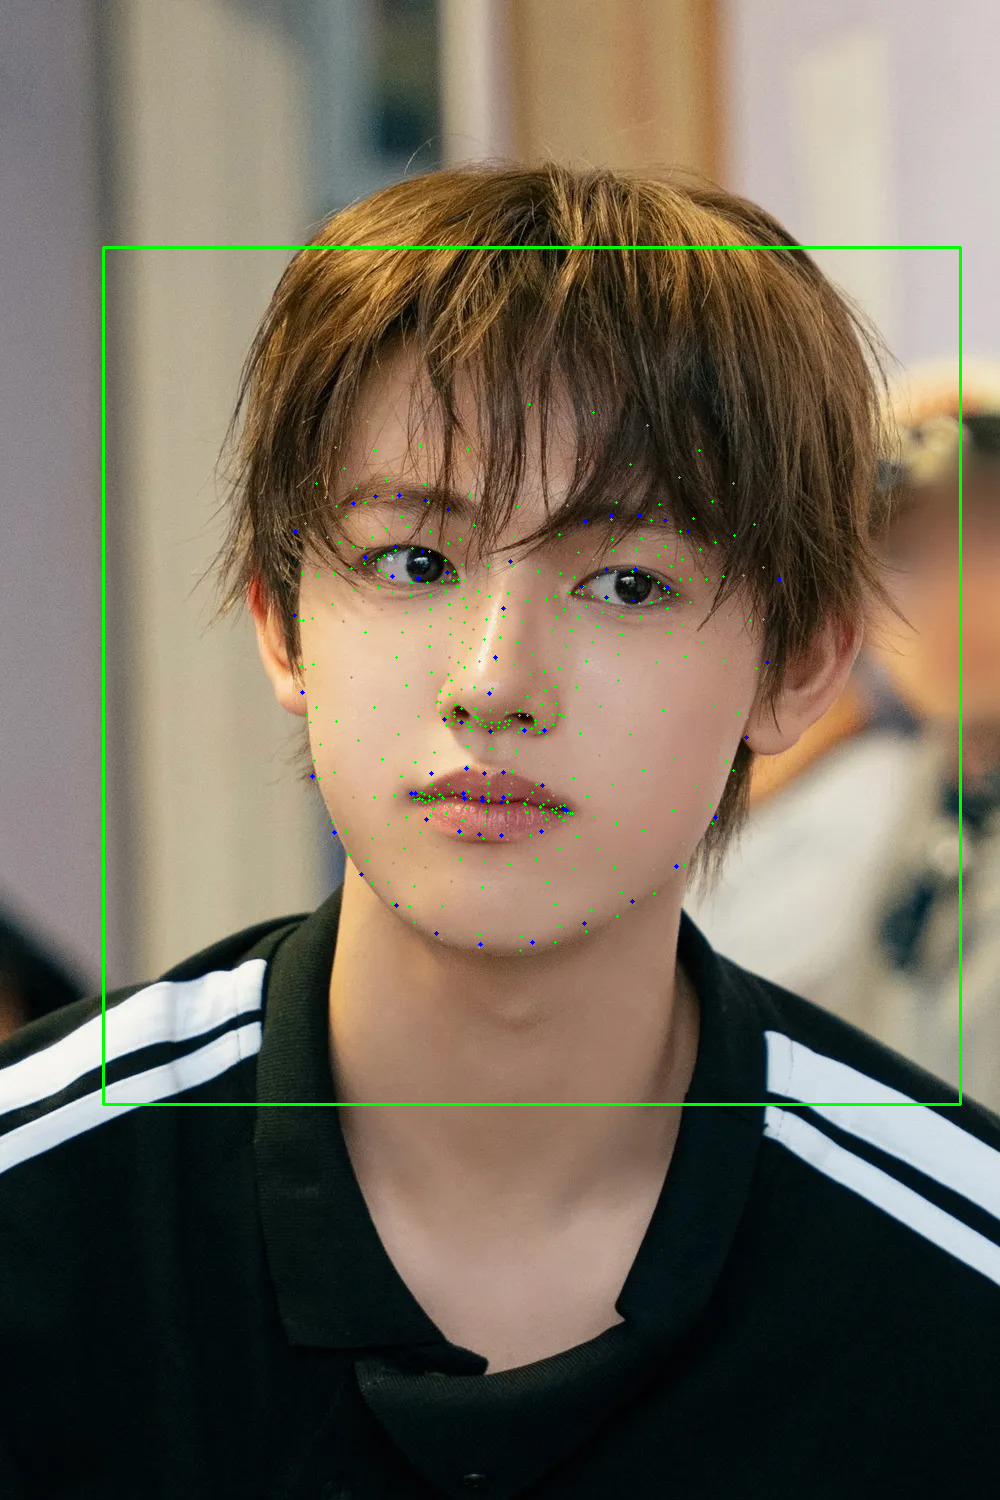

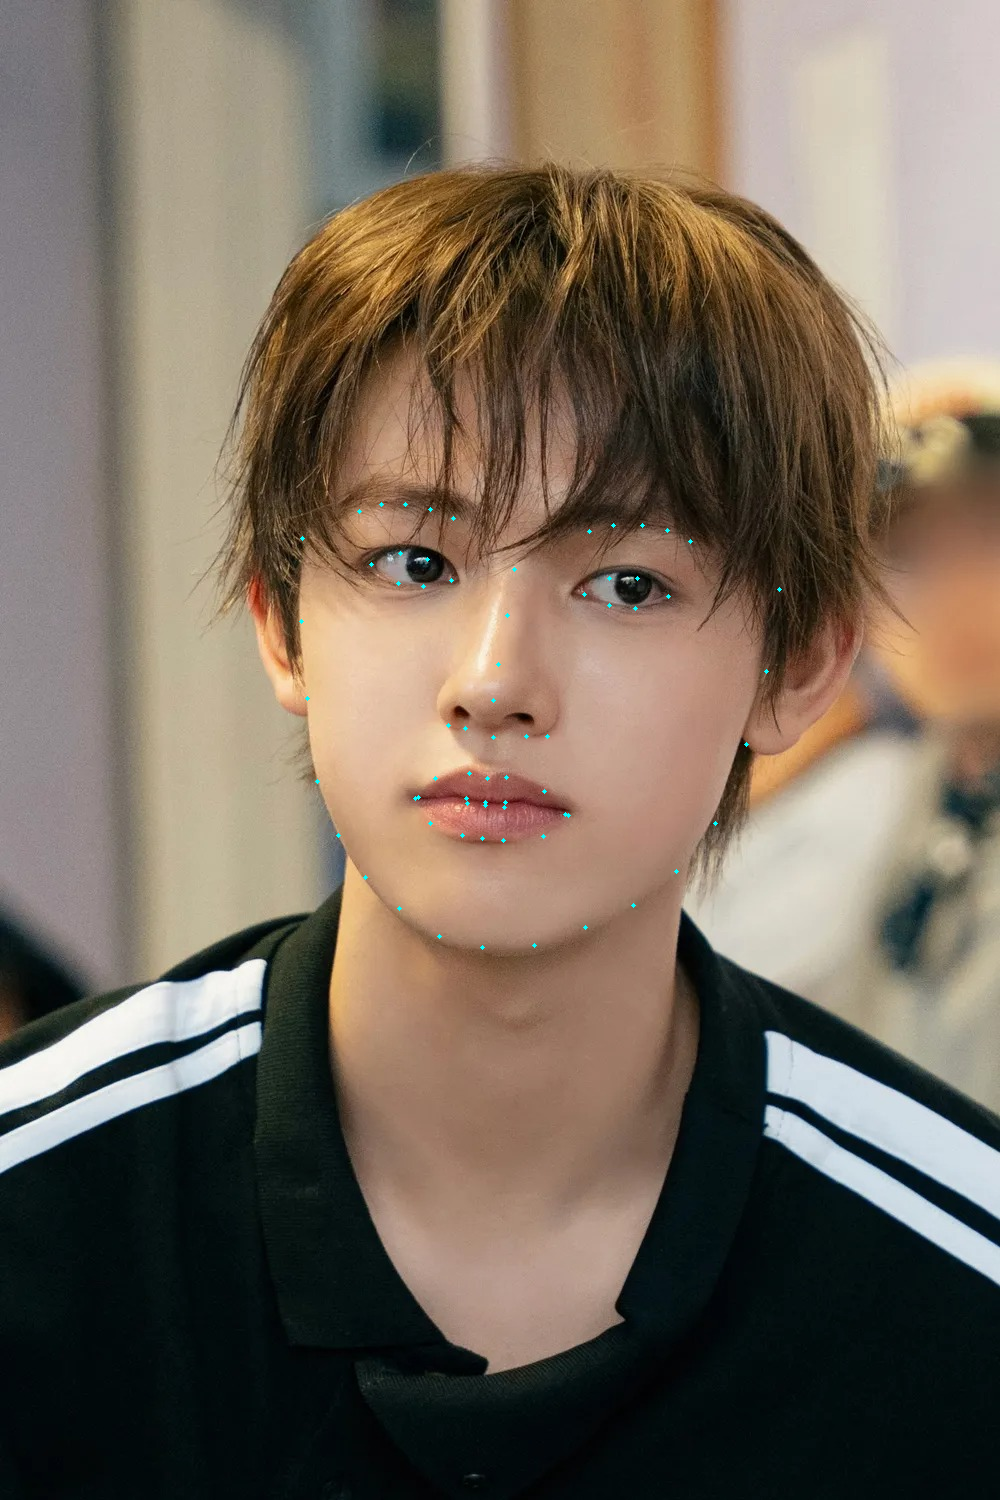

In [ ]:
from google.colab import files
from PIL import Image
import numpy as np
import cv2

# 1) 이미지 업로드
uploaded = files.upload()
img_path = next(iter(uploaded.keys()))
image_rgb = np.array(Image.open(img_path).convert("RGB"))

# 2) 모델 로드
model = FaceMap_3DMM.from_pretrained()
mp_canonical_vertices, mp_uvs, mp_faces, mp_face_uvs = load_canonical_obj()

# 3) MediaPipe Task로 468 landmark 추출
with create_face_landmarker("/content/face_landmarker.task") as landmarker:
    mp468, mp_matrix, mp_result = infer_mediapipe_task(
        landmarker,
        image_rgb,
        use_first_468=True,
    )

# 4) MediaPipe landmark 기반 얼굴 bbox 생성
bbox = get_face_bbox_from_mp468(
    mp468,
    image_rgb.shape,
    padding=0.28,     # 0.20 ~ 0.35 정도에서 조절
    make_square=True,
)

# 5) Qualcomm 3DMM으로 sparse 68 추출
q68_2d, q68_3d, raw265 = infer_qualcomm_sparse68(
    model,
    image_rgb,
    bbox=bbox,
)

# 6) Qualcomm 68 <-> MediaPipe 468 매핑 생성
q68_to_mp, q68_aligned = build_q68_to_mp_map(
    q68_2d,
    mp468[:, :2],
)

# 7) MediaPipe canonical topology로 warp
runtime_vertices = warp_mp_mesh_from_q68(
    mp_canonical_vertices,
    q68_to_mp,
    q68_3d,
    smoothing=1e-2,
)

# 8) 저장
np.save("/content/q68_to_mp.npy", q68_to_mp)
np.save("/content/runtime_vertices.npy", runtime_vertices)
export_obj(
    "/content/runtime_mp_mesh.obj",
    runtime_vertices,
    mp_faces,
    mp_uvs,
    mp_face_uvs,
)

# 9) 디버그 시각화
dbg_bbox = image_rgb.copy()
x0, y0, x1, y1 = bbox
cv2.rectangle(dbg_bbox, (x0, y0), (x1, y1), (0, 255, 0), 2)

dbg_mp = draw_points(dbg_bbox, mp468[:, :2], color=(0, 255, 0), radius=1)
dbg_q68 = draw_points(dbg_mp, q68_2d, color=(255, 0, 0), radius=2)
dbg_q68_aligned = draw_points(image_rgb, q68_aligned, color=(255, 255, 0), radius=2)

print("image shape:", image_rgb.shape)
print("mp468 shape:", mp468.shape)
print("q68_2d shape:", q68_2d.shape)
print("bbox:", bbox)
print("saved: /content/q68_to_mp.npy")
print("saved: /content/runtime_vertices.npy")
print("saved: /content/runtime_mp_mesh.obj")

display(Image.fromarray(dbg_q68))
display(Image.fromarray(dbg_q68_aligned))

show_mesh_plotly(runtime_vertices, mp_faces, title="Qualcomm -> MediaPipe topology")


#52로

##환경

In [ ]:
!pip -q install "qai-hub-models[facemap-3dmm]" mediapipe opencv-python-headless torch torchvision scikit-learn pandas
!wget -q -O /content/face_landmarker.task \
  https://storage.googleapis.com/mediapipe-models/face_landmarker/face_landmarker/float16/latest/face_landmarker.task


In [ ]:
import os
import cv2
import json
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
import mediapipe as mp

from PIL import Image
from google.colab import files
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from qai_hub_models.models.facemap_3dmm.model import FaceMap_3DMM

BaseOptions = mp.tasks.BaseOptions
FaceLandmarker = mp.tasks.vision.FaceLandmarker
FaceLandmarkerOptions = mp.tasks.vision.FaceLandmarkerOptions
VisionRunningMode = mp.tasks.vision.RunningMode


def create_face_landmarker(model_path="/content/face_landmarker.task", num_faces=1):
    options = FaceLandmarkerOptions(
        base_options=BaseOptions(model_asset_path=model_path),
        running_mode=VisionRunningMode.IMAGE,
        num_faces=num_faces,
        min_face_detection_confidence=0.5,
        min_face_presence_confidence=0.5,
        min_tracking_confidence=0.5,
        output_face_blendshapes=True,
        output_facial_transformation_matrixes=True,
    )
    return FaceLandmarker.create_from_options(options)


def infer_mediapipe_teacher(landmarker, image_rgb):
    h, w = image_rgb.shape[:2]
    mp_image = mp.Image(image_format=mp.ImageFormat.SRGB, data=image_rgb)
    result = landmarker.detect(mp_image)

    if not result.face_landmarks or not result.face_blendshapes:
        return None

    pts = np.array(
        [[lm.x * w, lm.y * h, lm.z * w] for lm in result.face_landmarks[0]],
        dtype=np.float32,
    )

    blend_items = result.face_blendshapes[0]
    names = [x.category_name for x in blend_items]
    scores = np.array([x.score for x in blend_items], dtype=np.float32)

    matrix = None
    if result.facial_transformation_matrixes:
        matrix = np.array(result.facial_transformation_matrixes[0], dtype=np.float32)

    return {
        "landmarks": pts,
        "blendshape_names": names,
        "blendshape_scores": scores,
        "matrix": matrix,
    }


def get_face_bbox_from_mp468(mp468, image_shape, padding=0.28, make_square=True):
    h, w = image_shape[:2]
    xs = mp468[:, 0]
    ys = mp468[:, 1]

    x0, x1 = xs.min(), xs.max()
    y0, y1 = ys.min(), ys.max()

    bw = x1 - x0
    bh = y1 - y0

    x0 -= bw * padding
    x1 += bw * padding
    y0 -= bh * padding
    y1 += bh * padding

    if make_square:
        cx = (x0 + x1) / 2.0
        cy = (y0 + y1) / 2.0
        size = max(x1 - x0, y1 - y0)
        x0 = cx - size / 2.0
        x1 = cx + size / 2.0
        y0 = cy - size / 2.0
        y1 = cy + size / 2.0

    x0 = int(np.clip(np.floor(x0), 0, w - 1))
    y0 = int(np.clip(np.floor(y0), 0, h - 1))
    x1 = int(np.clip(np.ceil(x1), 0, w - 1))
    y1 = int(np.clip(np.ceil(y1), 0, h - 1))

    return x0, y0, x1, y1


def infer_qualcomm_265(model, image_rgb, bbox):
    x0, y0, x1, y1 = bbox
    crop = image_rgb[y0:y1 + 1, x0:x1 + 1]
    crop = cv2.resize(crop, (128, 128), interpolation=cv2.INTER_LINEAR)

    inp = torch.from_numpy(crop).float() / 255.0
    inp = inp.permute(2, 0, 1).unsqueeze(0)

    with torch.no_grad():
        out = model(inp)[0].cpu().numpy().astype(np.float32)

    return out


class BlendshapeMLP(nn.Module):
    def __init__(self, in_dim=265, out_dim=52):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, 256),
            nn.ReLU(),
            nn.Linear(256, 256),
            nn.ReLU(),
            nn.Linear(256, out_dim),
            nn.Sigmoid(),
        )

    def forward(self, x):
        return self.net(x)


##실행


In [ ]:
uploaded = files.upload()
video_path = next(iter(uploaded.keys()))

qualcomm_model = FaceMap_3DMM.from_pretrained()

rows_x = []
rows_y = []
blendshape_names = None

cap = cv2.VideoCapture(video_path)

with create_face_landmarker("/content/face_landmarker.task") as landmarker:
    frame_idx = 0
    keep_every = 3  # 프레임 너무 많으면 2~5 정도로 샘플링

    while True:
        ok, frame_bgr = cap.read()
        if not ok:
            break

        if frame_idx % keep_every != 0:
            frame_idx += 1
            continue

        frame_rgb = cv2.cvtColor(frame_bgr, cv2.COLOR_BGR2RGB)

        teacher = infer_mediapipe_teacher(landmarker, frame_rgb)
        if teacher is None:
            frame_idx += 1
            continue

        mp468 = teacher["landmarks"][:468]
        bbox = get_face_bbox_from_mp468(mp468, frame_rgb.shape, padding=0.28, make_square=True)

        try:
            x265 = infer_qualcomm_265(qualcomm_model, frame_rgb, bbox)
        except Exception:
            frame_idx += 1
            continue




Saving d0.mp4 to d0.mp4
